# 01 - Preprocessing

This notebook loads, cleans, transforms, scales, and prepares the time series dataset for global solar radiation forecasting.

The output files generated here will be used by the following notebooks:

- `02_models.ipynb`
- `03_optimization.ipynb`
- `04_analysis.ipynb`

In [3]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [4]:
BASE_DIR = "/home/jovyan/work"

DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
SCALER_DIR = os.path.join(OUTPUT_DIR, "scalers")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
ARRAYS_DIR = os.path.join(OUTPUT_DIR, "arrays")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(ARRAYS_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR: /home/jovyan/work
DATA_DIR: /home/jovyan/work/data
OUTPUT_DIR: /home/jovyan/work/outputs


In [6]:
CONFIG = {
    "file_name": "EMA--OMUAQ_Table1.txt",
    "timestamp_column": "TIMESTAMP",
    "target": "SolRad_Avg",
    "window_size": 12,
    "horizon": 6,
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "irradiance_threshold": 50
}

file_path = os.path.join(DATA_DIR, CONFIG["file_name"])

print("File path:", file_path)

File path: /home/jovyan/work/data/EMA--OMUAQ_Table1.txt


In [7]:
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (28053, 11)


,TIMESTAMP,RECORD,BattV_Min,TempAir_Avg,HumRel,SolRad_Avg,PreBar_Avg,Precip_Tot,VelVto_S_WVT,DirVto_D1_WVT,DirVto_SD1_WVT
0,2017-12-01 14:00:00,0,12.99,20.60,26.34,770.0,57.65,0.0,4.213,101.0,5.112
1,2017-12-01 14:10:00,1,12.99,20.54,26.56,747.6,807.00,0.0,4.627,95.6,14.540
2,2017-12-01 14:20:00,2,12.99,20.71,25.15,722.6,807.00,0.0,3.984,94.5,22.770
3,2017-12-01 14:30:00,3,12.98,20.94,22.78,700.1,807.00,0.0,4.789,92.9,15.340
4,2017-12-01 14:40:00,4,12.98,20.85,24.51,676.4,807.00,0.0,4.494,91.7,17.280


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28053 entries, 0 to 28052
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TIMESTAMP       28053 non-null  object 
 1   RECORD          28053 non-null  int64  
 2   BattV_Min       28053 non-null  float64
 3   TempAir_Avg     28053 non-null  float64
 4   HumRel          28053 non-null  float64
 5   SolRad_Avg      28053 non-null  float64
 6   PreBar_Avg      28053 non-null  float64
 7   Precip_Tot      28053 non-null  float64
 8   VelVto_S_WVT    28053 non-null  float64
 9   DirVto_D1_WVT   28053 non-null  float64
 10  DirVto_SD1_WVT  28053 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 2.4+ MB


,RECORD,BattV_Min,TempAir_Avg,HumRel,SolRad_Avg,PreBar_Avg,Precip_Tot,VelVto_S_WVT,DirVto_D1_WVT,DirVto_SD1_WVT
count,28053.000000,28053.000000,28053.000000,28053.000000,28053.000000,28053.000000,28053.000000,28053.000000,28053.000000,28053.000000
mean,14026.000000,12.684874,17.773839,56.049883,255.781435,807.153982,0.005867,3.644981,138.789552,14.955780
std,8098.347887,0.273347,6.460866,24.206528,349.445768,5.027769,0.157917,1.641977,88.345088,11.812507
min,0.000000,12.240000,-0.695000,7.796000,0.000000,57.650000,0.000000,0.095000,0.000000,0.000000
25%,7013.000000,12.450000,13.140000,34.930000,0.000000,806.000000,0.000000,2.428000,73.640000,8.570000
50%,14026.000000,12.580000,17.310000,54.030000,0.374000,807.000000,0.000000,3.483000,89.800000,10.880000
75%,21039.000000,12.940000,22.670000,77.540000,525.100000,809.000000,0.000000,4.735000,242.300000,16.770000
max,28052.000000,13.510000,35.810000,100.000000,1220.000000,814.000000,13.000000,11.200000,359.800000,102.500000


In [9]:
df[CONFIG["timestamp_column"]] = pd.to_datetime(df[CONFIG["timestamp_column"]])

df = df.sort_values(CONFIG["timestamp_column"])
df = df.set_index(CONFIG["timestamp_column"])

print("Initial date:", df.index.min())
print("Final date:", df.index.max())
print("Shape:", df.shape)

df.head()

Initial date: 2017-12-01 14:00:00
Final date: 2018-06-14 09:20:00
Shape: (28053, 10)


,RECORD,BattV_Min,TempAir_Avg,HumRel,SolRad_Avg,PreBar_Avg,Precip_Tot,VelVto_S_WVT,DirVto_D1_WVT,DirVto_SD1_WVT
TIMESTAMP,,,,,,,,,,
2017-12-01 14:00:00,0,12.99,20.60,26.34,770.0,57.65,0.0,4.213,101.0,5.112
2017-12-01 14:10:00,1,12.99,20.54,26.56,747.6,807.00,0.0,4.627,95.6,14.540
2017-12-01 14:20:00,2,12.99,20.71,25.15,722.6,807.00,0.0,3.984,94.5,22.770
2017-12-01 14:30:00,3,12.98,20.94,22.78,700.1,807.00,0.0,4.789,92.9,15.340
2017-12-01 14:40:00,4,12.98,20.85,24.51,676.4,807.00,0.0,4.494,91.7,17.280


In [10]:
missing_values = df.isnull().sum()
missing_values

RECORD            0
BattV_Min         0
TempAir_Avg       0
HumRel            0
SolRad_Avg        0
PreBar_Avg        0
Precip_Tot        0
VelVto_S_WVT      0
DirVto_D1_WVT     0
DirVto_SD1_WVT    0
dtype: int64

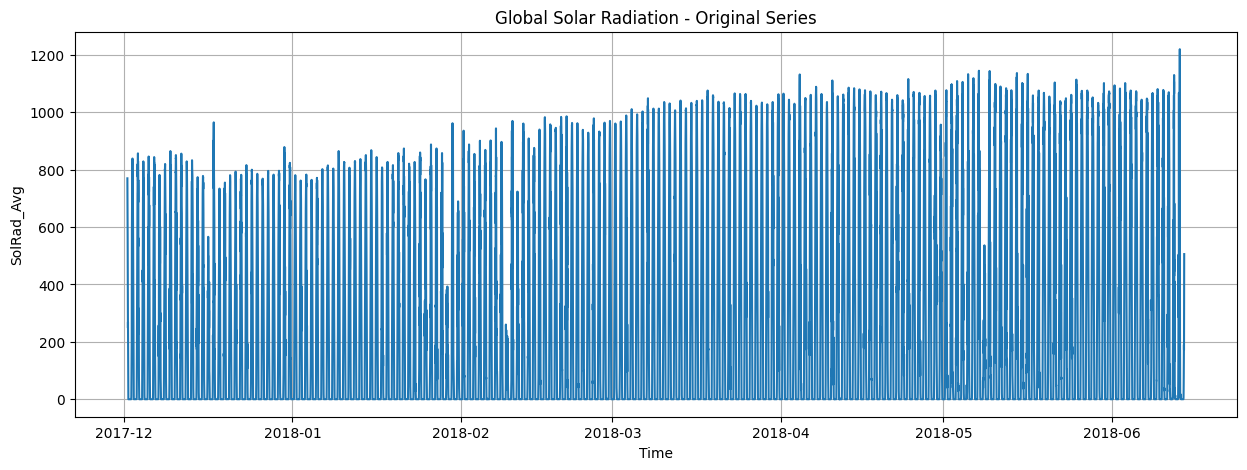

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df[CONFIG["target"]])
plt.title("Global Solar Radiation - Original Series")
plt.xlabel("Time")
plt.ylabel("SolRad_Avg")
plt.grid(True)
plt.show()

In [12]:
df["hour"] = df.index.hour
df["dayofyear"] = df.index.dayofyear
df["month"] = df.index.month

df.head()

,RECORD,BattV_Min,TempAir_Avg,HumRel,SolRad_Avg,PreBar_Avg,Precip_Tot,VelVto_S_WVT,DirVto_D1_WVT,DirVto_SD1_WVT,hour,dayofyear,month
TIMESTAMP,,,,,,,,,,,,,
2017-12-01 14:00:00,0,12.99,20.60,26.34,770.0,57.65,0.0,4.213,101.0,5.112,14,335,12
2017-12-01 14:10:00,1,12.99,20.54,26.56,747.6,807.00,0.0,4.627,95.6,14.540,14,335,12
2017-12-01 14:20:00,2,12.99,20.71,25.15,722.6,807.00,0.0,3.984,94.5,22.770,14,335,12
2017-12-01 14:30:00,3,12.98,20.94,22.78,700.1,807.00,0.0,4.789,92.9,15.340,14,335,12
2017-12-01 14:40:00,4,12.98,20.85,24.51,676.4,807.00,0.0,4.494,91.7,17.280,14,335,12


In [13]:
features = [
    "TempAir_Avg",
    "HumRel",
    "PreBar_Avg",
    "VelVto_S_WVT",
    "DirVto_D1_WVT",
    "DirVto_SD1_WVT",
    "hour",
    "dayofyear",
    "month"
]

target = CONFIG["target"]

print("Features:", features)
print("Target:", target)

Features: ['TempAir_Avg', 'HumRel', 'PreBar_Avg', 'VelVto_S_WVT', 'DirVto_D1_WVT', 'DirVto_SD1_WVT', 'hour', 'dayofyear', 'month']
Target: SolRad_Avg


In [14]:
original_shape = df.shape

df = df[
    (df["TempAir_Avg"] > -20) &
    (df["TempAir_Avg"] < 60)
]

df = df[
    (df["PreBar_Avg"] > 700) &
    (df["PreBar_Avg"] < 900)
]

df = df[
    (df["HumRel"] >= 0) &
    (df["HumRel"] <= 100)
]

df = df[
    (df["SolRad_Avg"] >= 0)
]

print("Original shape:", original_shape)
print("Cleaned shape:", df.shape)
print("Removed rows:", original_shape[0] - df.shape[0])

Original shape: (28053, 13)
Cleaned shape: (28052, 13)
Removed rows: 1


In [15]:
df.isnull().sum()

RECORD            0
BattV_Min         0
TempAir_Avg       0
HumRel            0
SolRad_Avg        0
PreBar_Avg        0
Precip_Tot        0
VelVto_S_WVT      0
DirVto_D1_WVT     0
DirVto_SD1_WVT    0
hour              0
dayofyear         0
month             0
dtype: int64

In [16]:
df[features + [target]].describe()

,TempAir_Avg,HumRel,PreBar_Avg,VelVto_S_WVT,DirVto_D1_WVT,DirVto_SD1_WVT,hour,dayofyear,month,SolRad_Avg
count,28052.000000,28052.000000,28052.000000,28052.000000,28052.000000,28052.000000,28052.000000,28052.000000,28052.000000,28052.000000
mean,17.773738,56.050942,807.180700,3.644961,138.790899,14.956130,11.500178,124.470626,4.621489,255.763104
std,6.460959,24.206309,2.291811,1.642003,88.346375,11.812571,6.925622,106.517784,3.493599,349.438508
min,-0.695000,7.796000,800.000000,0.095000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,13.137500,34.930000,806.000000,2.428000,73.640000,8.570000,5.000000,49.000000,2.000000,0.000000
50%,17.310000,54.030000,807.000000,3.483000,89.800000,10.880000,12.000000,98.000000,4.000000,0.370500
75%,22.670000,77.540000,809.000000,4.735000,242.300000,16.770000,18.000000,147.000000,5.000000,525.100000
max,35.810000,100.000000,814.000000,11.200000,359.800000,102.500000,23.000000,365.000000,12.000000,1220.000000


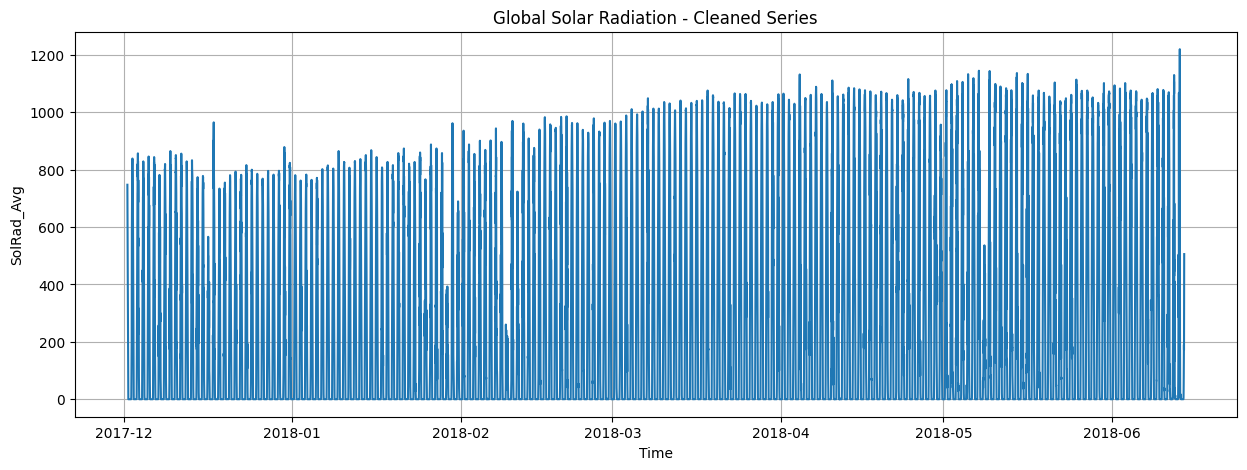

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df[target])
plt.title("Global Solar Radiation - Cleaned Series")
plt.xlabel("Time")
plt.ylabel("SolRad_Avg")
plt.grid(True)
plt.show()

In [18]:
df["is_daylight"] = df[target] > CONFIG["irradiance_threshold"]

print(df["is_daylight"].value_counts())
print(df["is_daylight"].value_counts(normalize=True))

is_daylight
False    15484
True     12568
Name: count, dtype: int64
is_daylight
False    0.551975
True     0.448025
Name: proportion, dtype: float64


In [19]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)

X_scaled shape: (28052, 9)
y_scaled shape: (28052, 1)


In [20]:
joblib.dump(scaler_X, os.path.join(SCALER_DIR, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(SCALER_DIR, "scaler_y.pkl"))

print("Scalers saved.")

Scalers saved.


In [21]:
def create_sequences(X, y, timestamps, daylight_flags, window_size, horizon):
    X_seq = []
    y_seq = []
    ts_seq = []
    daylight_seq = []

    for i in range(window_size, len(X) - horizon):
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i + horizon])
        ts_seq.append(timestamps[i + horizon])
        daylight_seq.append(daylight_flags[i + horizon])

    return (
        np.array(X_seq),
        np.array(y_seq),
        np.array(ts_seq),
        np.array(daylight_seq)
    )

In [22]:
X_seq, y_seq, timestamps_seq, daylight_seq = create_sequences(
    X=X_scaled,
    y=y_scaled,
    timestamps=df.index.to_numpy(),
    daylight_flags=df["is_daylight"].to_numpy(),
    window_size=CONFIG["window_size"],
    horizon=CONFIG["horizon"]
)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)
print("timestamps_seq:", timestamps_seq.shape)
print("daylight_seq:", daylight_seq.shape)

X_seq: (28034, 12, 9)
y_seq: (28034, 1)
timestamps_seq: (28034,)
daylight_seq: (28034,)


In [23]:
n_samples = len(X_seq)

train_size = int(n_samples * CONFIG["train_ratio"])
val_size = int(n_samples * CONFIG["val_ratio"])

test_size = n_samples - train_size - val_size

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]
timestamps_train = timestamps_seq[:train_size]
daylight_train = daylight_seq[:train_size]

X_val = X_seq[train_size:train_size + val_size]
y_val = y_seq[train_size:train_size + val_size]
timestamps_val = timestamps_seq[train_size:train_size + val_size]
daylight_val = daylight_seq[train_size:train_size + val_size]

X_test = X_seq[train_size + val_size:]
y_test = y_seq[train_size + val_size:]
timestamps_test = timestamps_seq[train_size + val_size:]
daylight_test = daylight_seq[train_size + val_size:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (19623, 12, 9) (19623, 1)
Validation: (4205, 12, 9) (4205, 1)
Test: (4206, 12, 9) (4206, 1)


In [24]:
print("Train period:")
print(timestamps_train[0], "to", timestamps_train[-1])

print("\nValidation period:")
print(timestamps_val[0], "to", timestamps_val[-1])

print("\nTest period:")
print(timestamps_test[0], "to", timestamps_test[-1])

Train period:
2017-12-01T17:10:00.000000000 to 2018-04-16T23:30:00.000000000

Validation period:
2018-04-16T23:40:00.000000000 to 2018-05-16T04:20:00.000000000

Test period:
2018-05-16T04:30:00.000000000 to 2018-06-14T09:20:00.000000000


In [25]:
np.save(os.path.join(ARRAYS_DIR, "X_train.npy"), X_train)
np.save(os.path.join(ARRAYS_DIR, "y_train.npy"), y_train)

np.save(os.path.join(ARRAYS_DIR, "X_val.npy"), X_val)
np.save(os.path.join(ARRAYS_DIR, "y_val.npy"), y_val)

np.save(os.path.join(ARRAYS_DIR, "X_test.npy"), X_test)
np.save(os.path.join(ARRAYS_DIR, "y_test.npy"), y_test)

np.save(os.path.join(ARRAYS_DIR, "timestamps_train.npy"), timestamps_train)
np.save(os.path.join(ARRAYS_DIR, "timestamps_val.npy"), timestamps_val)
np.save(os.path.join(ARRAYS_DIR, "timestamps_test.npy"), timestamps_test)

np.save(os.path.join(ARRAYS_DIR, "daylight_train.npy"), daylight_train)
np.save(os.path.join(ARRAYS_DIR, "daylight_val.npy"), daylight_val)
np.save(os.path.join(ARRAYS_DIR, "daylight_test.npy"), daylight_test)

print("Arrays saved in:", ARRAYS_DIR)

Arrays saved in: /home/jovyan/work/outputs/arrays


In [26]:
CONFIG["features"] = features
CONFIG["n_features"] = len(features)
CONFIG["n_samples"] = int(n_samples)
CONFIG["train_size"] = int(train_size)
CONFIG["val_size"] = int(val_size)
CONFIG["test_size"] = int(test_size)

config_path = os.path.join(OUTPUT_DIR, "preprocessing_config.json")

with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)

print("Configuration saved in:", config_path)

Configuration saved in: /home/jovyan/work/outputs/preprocessing_config.json


In [27]:
cleaned_data_path = os.path.join(OUTPUT_DIR, "cleaned_dataset.csv")

df.to_csv(cleaned_data_path)

print("Cleaned dataset saved in:", cleaned_data_path)

Cleaned dataset saved in: /home/jovyan/work/outputs/cleaned_dataset.csv


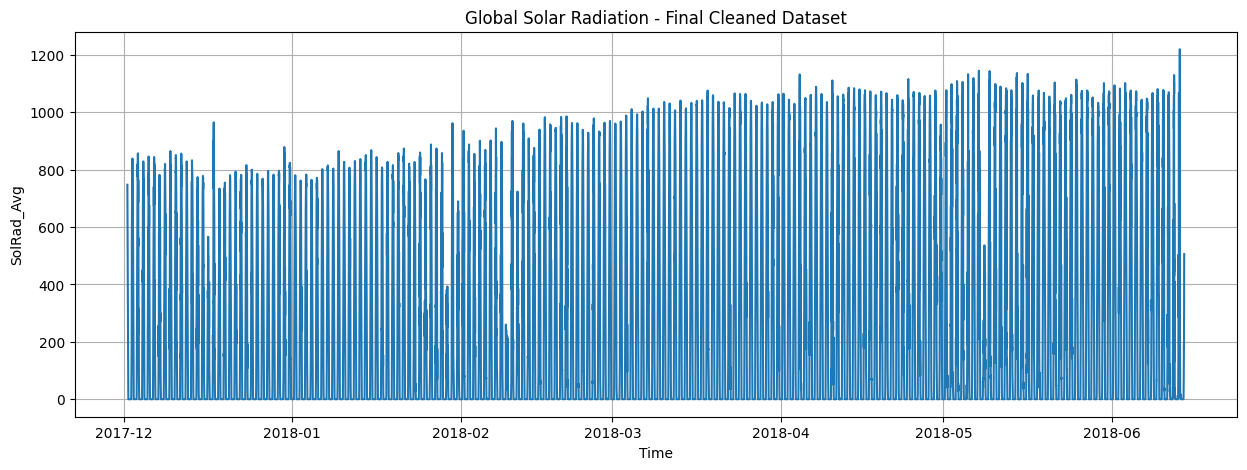

Figure saved in: /home/jovyan/work/outputs/figures/global_solar_radiation_cleaned.png


In [28]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df[target])
plt.title("Global Solar Radiation - Final Cleaned Dataset")
plt.xlabel("Time")
plt.ylabel("SolRad_Avg")
plt.grid(True)

figure_path = os.path.join(FIGURES_DIR, "global_solar_radiation_cleaned.png")
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved in:", figure_path)

In [29]:
summary = {
    "total_original_rows": int(original_shape[0]),
    "total_cleaned_rows": int(df.shape[0]),
    "removed_rows": int(original_shape[0] - df.shape[0]),
    "total_sequences": int(n_samples),
    "train_sequences": int(train_size),
    "validation_sequences": int(val_size),
    "test_sequences": int(test_size),
    "window_size": CONFIG["window_size"],
    "horizon": CONFIG["horizon"],
    "n_features": len(features),
    "target": target
}

summary

{'total_original_rows': 28053,
 'total_cleaned_rows': 28052,
 'removed_rows': 1,
 'total_sequences': 28034,
 'train_sequences': 19623,
 'validation_sequences': 4205,
 'test_sequences': 4206,
 'window_size': 12,
 'horizon': 6,
 'n_features': 9,
 'target': 'SolRad_Avg'}

In [30]:
summary_path = os.path.join(OUTPUT_DIR, "preprocessing_summary.json")

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Summary saved in:", summary_path)

Summary saved in: /home/jovyan/work/outputs/preprocessing_summary.json
